In [59]:
import mesa
import os
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid
from mesa.visualization import SolaraViz, make_space_component

# folders
current_dir = os.path.dirname(os.path.abspath("__file__"))
data_dir = os.path.join(current_dir, 'Data_generated')
plot_dir = os.path.join(data_dir, 'plots')
csv_dir = os.path.join(data_dir, 'csvs')

print("Data directory:", data_dir)
print("Plot directory:", plot_dir)
print("CSV directory:", csv_dir)

Data directory: d:\Research_projects\multi_agent_systems_practicum\models\full_grid_python_model\grid\Data_generated
Plot directory: d:\Research_projects\multi_agent_systems_practicum\models\full_grid_python_model\grid\Data_generated\plots
CSV directory: d:\Research_projects\multi_agent_systems_practicum\models\full_grid_python_model\grid\Data_generated\csvs


So python mesa usually has the following order of operations:
- Define an agent class
    - ```python
      class MyAgent(Agent):
          def __init__(self, model):
              super().__init__(model)
              # agent attributes
          
          def step(self):
              # agent behavior
      ```
- Define a model class
    - ```python
      class MyModel(Model):
          def __init__(self, N, width, height):
              self.num_agents = N
              self.grid = OrthogonalMooreGrid(width, height, torus=True, capacity=1)
          
          def step(self):
            self.agents.do("step")
      ```
- visualize the model (optional)

- initialize and run the model
    - ```python
      model = MyModel(N=100, width=10, height=10)
      for i in range(100):
            model.step()
      ```

So why start with the agent? Mostly conventional. It's easier to understand "what are the individual actors?" before "how do they interact as a system.". You need to know what agents can do before you can design a model that orchestrates them.


# Agent class
Lets create a simple agent class. Could you write here in natural language what it is doing?

"[write your explanation here]"

* What does __init__() do? What are these parameters?
* What does super().__init__() do?


In [60]:
class GridAgent(CellAgent):
    def __init__(self, model, cell):
        super().__init__(model) # This is calling the __init__ of the parent class (CellAgent in this case)
        self.cell = cell
        
    def step(self):
        self.cell = self.cell.neighborhood.select_random_cell()

In [61]:
# function to compute the maximum distance between any two agents (for collecting model level data)
def maxdistance(model):
    positions = [agent.cell.coordinate for agent in model.agents]
    max_dist = 0
    
    # Get grid dimensions
    width, height = model.grid.dimensions
    
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            x1, y1 = positions[i]
            x2, y2 = positions[j]
            # Calculate distance with torus wraparound (based on Mesa's internal method)
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            
            # Handle torus wraparound
            dx = min(dx, width - dx)
            dy = min(dy, height - dy)
            
            # Calculate Euclidean distance
            dist = (dx**2 + dy**2)**0.5
            if dist > max_dist:
                max_dist = dist
    return max_dist

class SimpleGridModel(mesa.Model):
    def __init__(self, width=10, height=10, numagents=2, seed = None):
        super().__init__(seed=seed) # This is calling the __init__ of the parent class (Model in this case) with a seed
        self.num_agents = numagents
        self.grid = OrthogonalMooreGrid((width, height), torus=True, random=self.random) # random needs to be set otherwise seed is not used
        # self = model instance, n = number of agents -> is consumed by create_agents, *args=random cell from all cells in the grid -> goes to GridAgent __init__
        GridAgent.create_agents(self, self.num_agents, self.random.choice(list(self.grid.all_cells.cells)))

        # collecting some data
        self.datacollector = mesa.DataCollector(model_reporters={"max_distance": maxdistance}, agent_reporters={"cell": lambda a: a.cell.coordinate})
         # collect initial data
         # model_reporters: A dictionary of functions that take a model as input and return a single value.
         # agent_reporters: A dictionary of functions that take an agent as input and return a single value.
         # The keys in these dictionaries will be the column names in the resulting DataFrame.
        self.datacollector.collect(self)

    def step(self):
        self.agents.do("step")
        self.datacollector.collect(self)

In [62]:
from mesa.visualization import SolaraViz, make_plot_component, make_space_component
# Visualization for native Mesa/solara vizualization
def agent_portrayal(agent):
    return {
        "color": "#FF0000",
        "size": 20,
    }

spaceviz = make_space_component(agent_portrayal=agent_portrayal)
max_distance_plot = make_plot_component("max_distance")

model = SimpleGridModel(10, 10, 2)
page = SolaraViz(model, [spaceviz, max_distance_plot], name="Grid Agent")
page

Cannot show ipywidgets in text

In [63]:
# Lets run the model
model = SimpleGridModel(100, 100, 10)
for _ in range(10): # run for 10 steps
    model.step()

# we can now retrieve the collected data
data_agents = model.datacollector.get_agent_vars_dataframe()
data_model = model.datacollector.get_model_vars_dataframe()

In [64]:
data_model.head()

,max_distance
0,0.000000
1,2.828427
2,4.123106
3,5.000000
4,6.403124


In [65]:
data_agents.head()

cell
Step AgentID          
0    1        (17, 28)
     2        (17, 28)
     3        (17, 28)
     4        (17, 28)
     5        (17, 28)

In [66]:
# write to csv
data_model.to_csv(os.path.join(csv_dir,'model_data.csv'))
data_agents.to_csv(os.path.join(csv_dir, 'agent_data.csv'))

print("go look in " + csv_dir)

go look in d:\Research_projects\multi_agent_systems_practicum\models\full_grid_python_model\grid\Data_generated\csvs


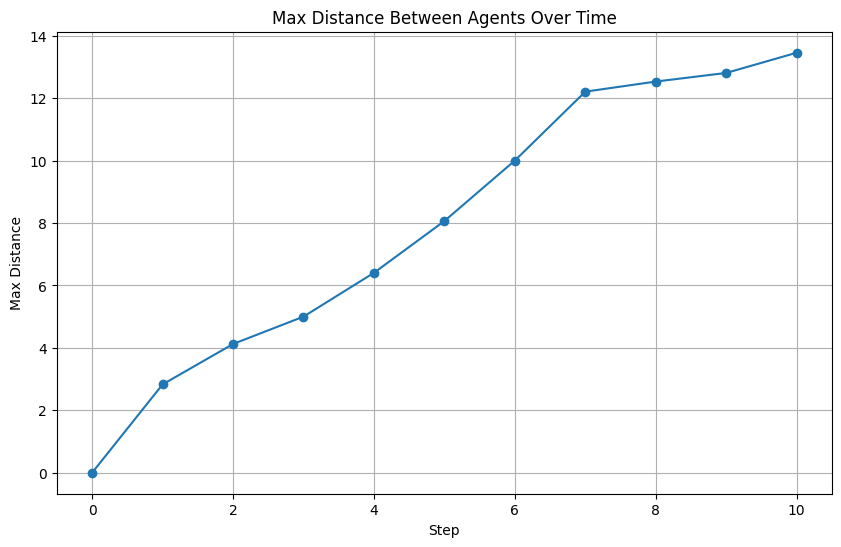

In [67]:
import matplotlib.pyplot as plt
# lets now plot the max distance over time and save a plot
plt.figure(figsize=(10, 6))
plt.plot(data_model.index, data_model['max_distance'], marker='o')
plt.title('Max Distance Between Agents Over Time')
plt.xlabel('Step')
plt.ylabel('Max Distance')
plt.grid()
plt.savefig(os.path.join(plot_dir, 'max_distance_plot.png'))
plt.show()


# Model
But wait. Were only collecting data from one model. How do we know that our model consistently having similar behavior? Different random picks will yield different initial positions and different movement patterns.

In [68]:
import pandas as pd
params = {"width": 10, "height": 10, "numagents": (2, 10)}

results_5seeds = mesa.batch_run(
    SimpleGridModel,
    parameters=params,
    iterations=5, # we now explicitly set seeds to run through
    max_steps=100,
    number_processes=1,
    data_collection_period=1,  # Need to collect every step
    display_progress=True,
)

results_5seeds = pd.DataFrame(results_5seeds)
# write away
results_5seeds.to_csv(os.path.join(csv_dir, 'batch_run_5seeds.csv'))
results_5seeds.head()

  0%|          | 0/10 [00:00<?, ?it/s]

,RunId,iteration,Step,width,height,numagents,max_distance,AgentID,cell
0,0,0,0,10,10,2,0.000000,1,"(4, 2)"
1,0,0,0,10,10,2,0.000000,2,"(4, 2)"
2,0,0,1,10,10,2,1.414214,1,"(4, 3)"
3,0,0,1,10,10,2,1.414214,2,"(3, 2)"
4,0,0,2,10,10,2,2.236068,1,"(5, 2)"


In [69]:
# Get model data by selecting only AgentID 1 (or any single agent)
model_only_data5s = results_5seeds[results_5seeds['AgentID'] == 1]

# Then drop the AgentID and cell columns since you don't need them
model_only_data5s = model_only_data5s.drop(columns=['AgentID', 'cell'])

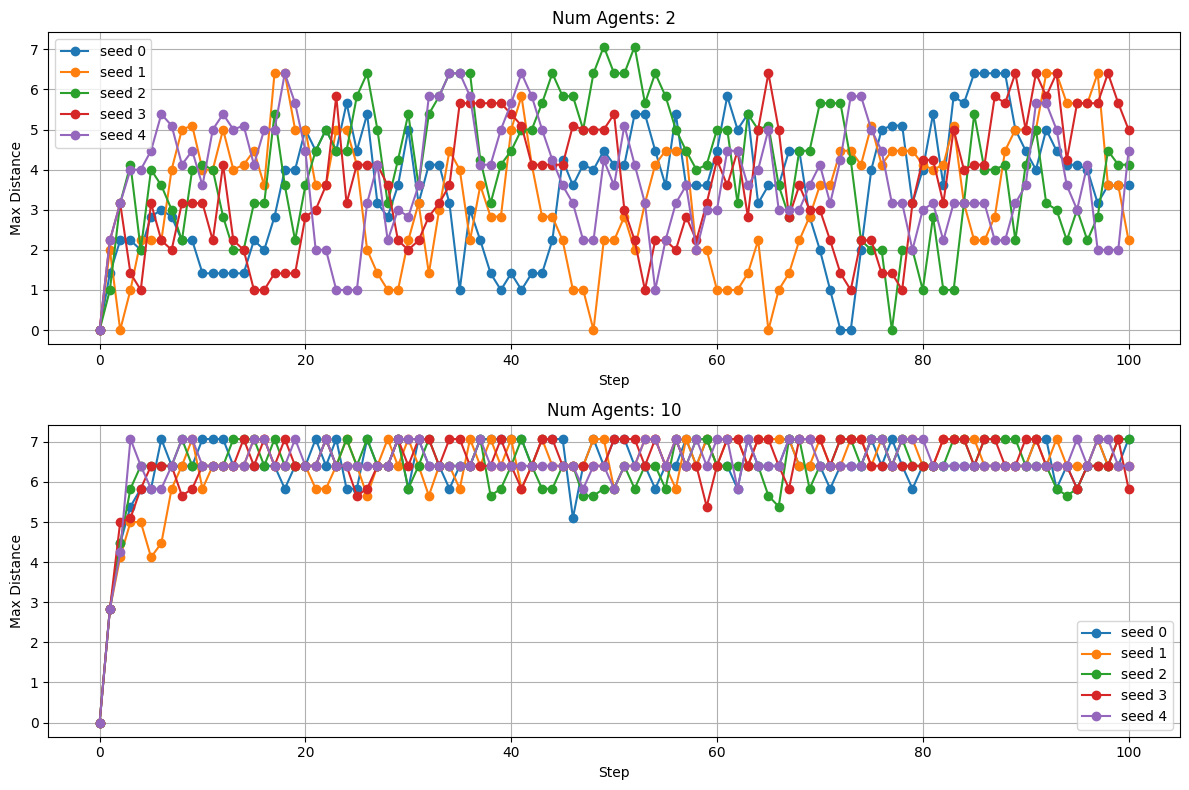

In [70]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
unique_numagents = model_only_data5s['numagents'].unique()
for i, numagents in enumerate(sorted(unique_numagents), 1):
    ax = fig.add_subplot(2, (len(unique_numagents) + 1) // 2, i)
    subset = model_only_data5s[model_only_data5s['numagents'] == numagents]
    for seed, group in subset.groupby('iteration'):
        # Sort by Step to ensure proper line connection
        group_sorted = group.sort_values('Step')
        ax.plot(group_sorted['Step'], group_sorted['max_distance'], 
               marker='o', label=f'seed {seed}')
    ax.set_title(f'Num Agents: {numagents}')
    ax.set_xlabel('Step')
    ax.set_ylabel('Max Distance')
    ax.grid()
    ax.legend()

# lets save the plot
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'batch_run_max_distance.png'))